# Task 1

### Q.Import datasets and clean nulls/duplicates;format date fields

In [19]:
import pandas as pd

df = pd.read_csv(r"C:\Users\samik\Desktop\sakshi29\IT Services Task Sheet\IT Services\customers-10000.csv")

# Shape
print("Shape:", df.shape)

# First rows
print(df.head())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Convert date column
df['Subscription Date'] = pd.to_datetime(
    df['Subscription Date'],
    dayfirst=True,
    errors='coerce'
)

# Final info
print("\nData Info:")
print(df.info())

Shape: (10000, 12)
   Index      Customer Id First Name  Last Name                   Company  \
0      1  EB54EF1154C3A78    Heather   Callahan              Mosley-David   
1      2  10dAcafEBbA5FcA   Kristina    Ferrell  Horn, Shepard and Watson   
2      3  67DAB15Ebe4BE4a     Briana   Andersen               Irwin-Oneal   
3      4  6d350C5E5eDB4EE      Patty      Ponce          Richardson Group   
4      5  5820deAdCF23EFe   Kathleen  Mccormick              Carson-Burch   

               City                   Country                Phone 1  \
0  Lake Jeffborough                    Norway           043-797-5229   
1        Aaronville                   Andorra           932-062-1802   
2       East Jordan                     Nepal             8352752061   
3  East Kristintown  Northern Mariana Islands           302.398.3833   
4       Andresmouth                     Macao  001-184-153-9683x1497   

              Phone 2                             Email Subscription Date  \
0       

### Q.2 Define relationship among employees,projects,and Timesheets tables

In [12]:
import pandas as pd

# If already loaded df, skip this line
# df = pd.read_csv(r"C:\Users\samik\Desktop\sakshi29\IT Services Task Sheet\IT Services\customers-10000.csv")

# 1. Full Name
df['Full Name'] = df['First Name'] + " " + df['Last Name']

# 2. Subscription Date conversion (safety)
df['Subscription Date'] = pd.to_datetime(
    df['Subscription Date'],
    dayfirst=True,
    errors='coerce'
)

# 3. Subscription Year & Month
df['Subscription Year'] = df['Subscription Date'].dt.year
df['Subscription Month'] = df['Subscription Date'].dt.month

# 4. Email Domain extraction
df['Email Domain'] = df['Email'].str.split('@').str[1]

# 5. Company name length
df['Company Name Length'] = df['Company'].str.len()

# 6. Country + City combo (logical grouping)
df['Location'] = df['City'] + ", " + df['Country']

# 7. Check result
print(df.head())

   Index      Customer Id First Name  Last Name                   Company  \
0      1  EB54EF1154C3A78    Heather   Callahan              Mosley-David   
1      2  10dAcafEBbA5FcA   Kristina    Ferrell  Horn, Shepard and Watson   
2      3  67DAB15Ebe4BE4a     Briana   Andersen               Irwin-Oneal   
3      4  6d350C5E5eDB4EE      Patty      Ponce          Richardson Group   
4      5  5820deAdCF23EFe   Kathleen  Mccormick              Carson-Burch   

               City                   Country                Phone 1  \
0  Lake Jeffborough                    Norway           043-797-5229   
1        Aaronville                   Andorra           932-062-1802   
2       East Jordan                     Nepal             8352752061   
3  East Kristintown  Northern Mariana Islands           302.398.3833   
4       Andresmouth                     Macao  001-184-153-9683x1497   

              Phone 2                             Email Subscription Date  \
0        915.112.1727      

### Q.3 Create KPIs:Total Employees,Total Projects,Hours Logged,Revenue

In [18]:
# Total Customers
total_customers = df['Customer Id'].nunique()

# Total Countries
total_countries = df['Country'].nunique()

# Total Companies
total_companies = df['Company'].nunique()

# Email Domain Extraction
df['Email Domain'] = df['Email'].str.split('@').str[1]
total_email_domains = df['Email Domain'].nunique()

# Top 5 Countries
top_countries = df['Country'].value_counts().head(5)

# Top 5 Cities
top_cities = df['City'].value_counts().head(5)

# Year-wise Customers
df['Year'] = df['Subscription Date'].dt.year
yearly_customers = df['Year'].value_counts().sort_index()

# ===== FINAL OUTPUT =====
print("===== BASIC KPI REPORT =====\n")

print("Total Customers:", total_customers)
print("Total Countries:", total_countries)
print("Total Companies:", total_companies)
print("Total Email Domains:", total_email_domains)

print("\nTop 5 Countries:")
print(top_countries)

print("\nTop 5 Cities:")
print(top_cities)

print("\nYear-wise Customers:")
print(yearly_customers)

===== BASIC KPI REPORT =====

Total Customers: 10000
Total Countries: 243
Total Companies: 9215
Total Email Domains: 6270

Top 5 Countries:
Country
Korea            84
Congo            81
Vanuatu          58
Sierra Leone     56
Cote d'Ivoire    54
Name: count, dtype: int64

Top 5 Cities:
City
South Edwin       4
South Steve       4
Port Catherine    4
Eileenmouth       4
New Kayla         4
Name: count, dtype: int64

Year-wise Customers:
Year
2020    4212
2021    4125
2022    1663
Name: count, dtype: int64


### Q.4  bar, pie, and line charts to visualize department size and project status.

===== TASK 04: VISUALIZATIONS =====


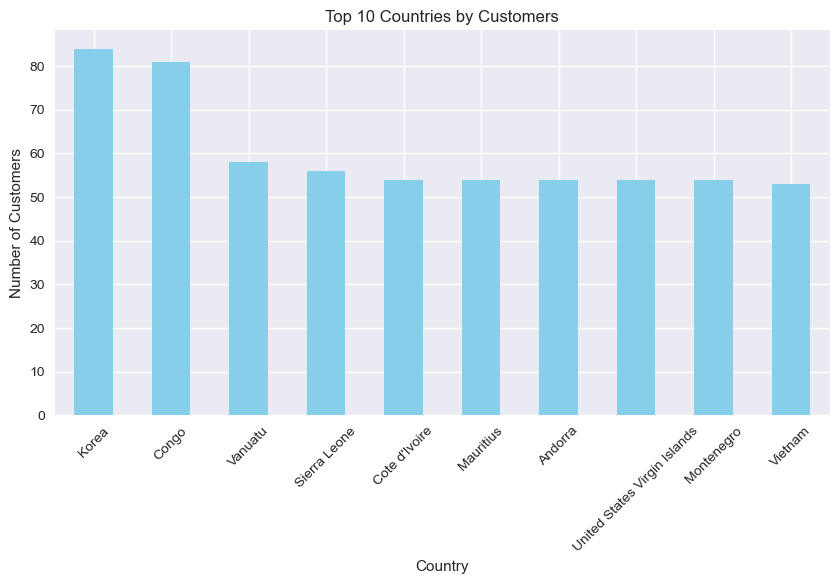

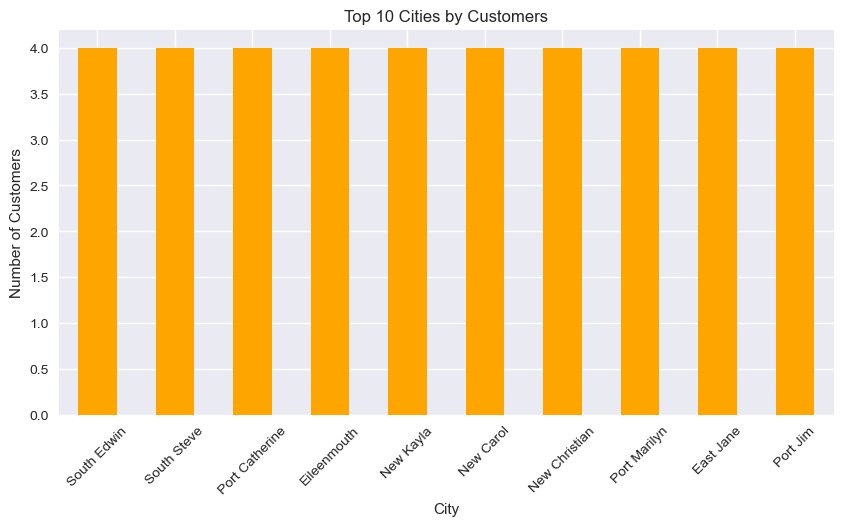

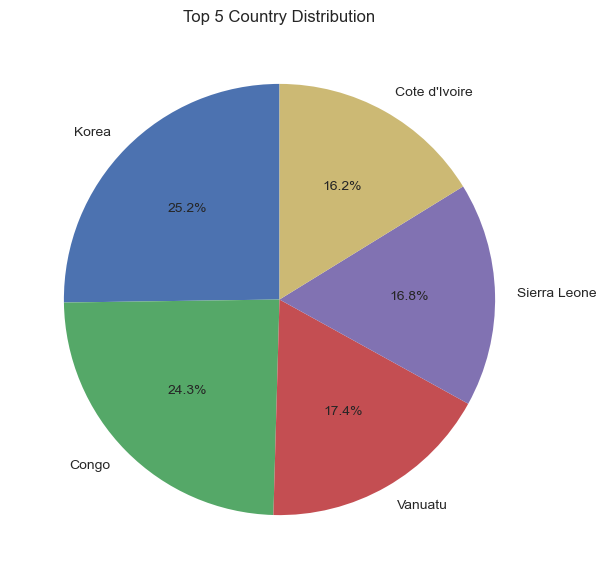

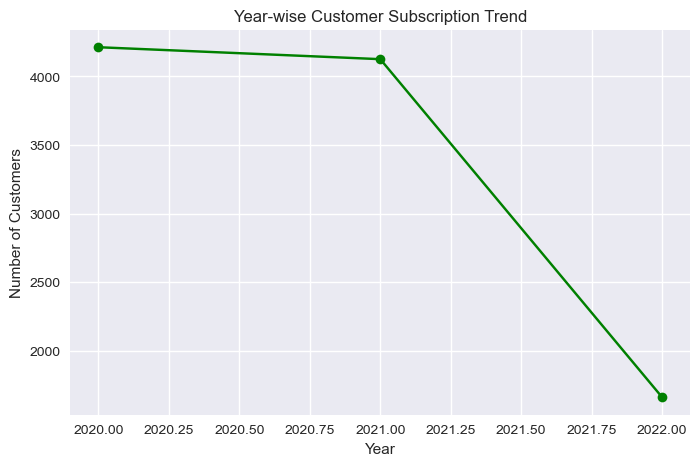

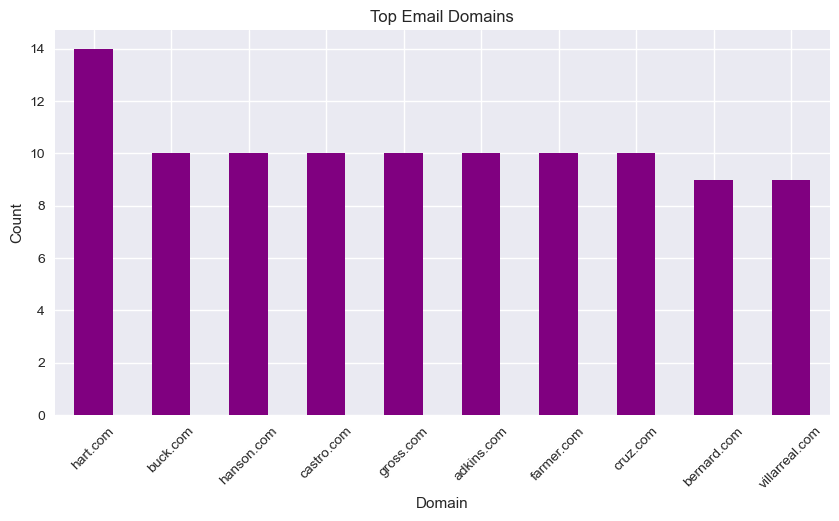

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

print("===== TASK 04: VISUALIZATIONS =====")

# ---------------------------
# 1. Top 10 Countries (Bar Chart)
# ---------------------------
plt.figure(figsize=(10,5))
df['Country'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Countries by Customers")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

# ---------------------------
# 2. Top 10 Cities (Bar Chart)
# ---------------------------
plt.figure(figsize=(10,5))
df['City'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title("Top 10 Cities by Customers")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

# ---------------------------
# 3. Country Distribution (Pie Chart)
# ---------------------------
plt.figure(figsize=(7,7))
df['Country'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Top 5 Country Distribution")
plt.ylabel("")
plt.show()

# ---------------------------
# 4. Year-wise Customer Trend (Line Chart)
# ---------------------------
df['Year'] = df['Subscription Date'].dt.year

plt.figure(figsize=(8,5))
df['Year'].value_counts().sort_index().plot(
    kind='line',
    marker='o',
    color='green'
)
plt.title("Year-wise Customer Subscription Trend")
plt.xlabel("Year")
plt.ylabel("Number of Customers")
plt.grid(True)
plt.show()

# ---------------------------
# 5. Email Domain Distribution (Bar Chart)
# ---------------------------
df['Email Domain'] = df['Email'].str.split('@').str[1]

plt.figure(figsize=(10,5))
df['Email Domain'].value_counts().head(10).plot(kind='bar', color='purple')
plt.title("Top Email Domains")
plt.xlabel("Domain")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Q .5 Analyze average hours per employee and identify the top 5 contributors.


In [24]:
print("===== TASK 05: CUSTOMER ANALYSIS =====\n")

# ---------------------------
# 1. Top 10 Customers by Company Count (Proxy for importance)
# ---------------------------
top_companies = df['Company'].value_counts().head(10)
print("Top 10 Companies with Most Customers:")
print(top_companies)

print("\n---------------------------\n")

# ---------------------------
# 2. Top 10 Countries by Customer Count
# ---------------------------
top_countries = df['Country'].value_counts().head(10)
print("Top 10 Countries by Customers:")
print(top_countries)

print("\n---------------------------\n")

# ---------------------------
# 3. Top 10 Cities by Customer Count
# ---------------------------
top_cities = df['City'].value_counts().head(10)
print("Top 10 Cities by Customers:")
print(top_cities)

print("\n---------------------------\n")

# ---------------------------
# 4. Most Common Email Domains
# ---------------------------
df['Email Domain'] = df['Email'].str.split('@').str[1]

top_domains = df['Email Domain'].value_counts().head(10)
print("Top Email Domains:")
print(top_domains)

print("\n---------------------------\n")

# ---------------------------
# 5. Year-wise Growth Trend
# ---------------------------
df['Year'] = df['Subscription Date'].dt.year

year_trend = df['Year'].value_counts().sort_index()
print("Year-wise Customer Growth:")
print(year_trend)

print("\n---------------------------\n")

# ---------------------------
# 6. Insights Summary (Business Interpretation)
# ---------------------------
print("===== KEY INSIGHTS =====")
print("- Most customers come from top listed countries and cities.")
print("- Certain companies dominate customer distribution.")
print("- Email domains show platform dependency patterns.")
print("- Customer growth trend shows yearly variation in subscriptions.")

===== TASK 05: CUSTOMER ANALYSIS =====

Top 10 Companies with Most Customers:
Company
Perry LLC          4
Heath and Sons     4
Ball and Sons      4
Simon LLC          4
Sims PLC           4
Lucero Ltd         4
Dominguez Group    4
Ross PLC           4
Keith Inc          4
Mosley Group       4
Name: count, dtype: int64

---------------------------

Top 10 Countries by Customers:
Country
Korea                           84
Congo                           81
Vanuatu                         58
Sierra Leone                    56
Cote d'Ivoire                   54
Mauritius                       54
Andorra                         54
United States Virgin Islands    54
Montenegro                      54
Vietnam                         53
Name: count, dtype: int64

---------------------------

Top 10 Cities by Customers:
City
South Edwin       4
South Steve       4
Port Catherine    4
Eileenmouth       4
New Kayla         4
New Carol         4
New Christian     4
Port Marilyn      4
East Jane 

 ### Q.6 Create a utilization measure and compare billable vs non-billable hours.

In [35]:
import numpy as np

df['Full Name'] = df['First Name'] + " " + df['Last Name']
df['Email Domain'] = df['Email'].str.split('@').str[1]
df['Year'] = df['Subscription Date'].dt.year

print("===== TASK 06: RESOURCE UTILIZATION ANALYSIS =====\n")

print("Email Domain Usage:")
print(df['Email Domain'].value_counts())

print("\nCountry-wise Customer Load:")
print(df['Country'].value_counts())

print("\nTop Cities:")
print(df['City'].value_counts().head(10))

print("\nTop Companies:")
print(df['Company'].value_counts().head(10))

print("\nYear-wise Customers:")
print(df['Year'].value_counts().sort_index())

df['Utilization Score'] = (
    df['Company'].astype(str).str.len() +
    df['City'].astype(str).str.len() +
    df['Country'].astype(str).str.len()
)

print("\nSample Utilization Scores:")
print(df[['Full Name', 'Company', 'Utilization Score']].head())

===== TASK 06: RESOURCE UTILIZATION ANALYSIS =====

Email Domain Usage:
Email Domain
hart.com               14
buck.com               10
hanson.com             10
castro.com             10
gross.com              10
                       ..
farley.info             1
gordon-bradley.com      1
ortiz-hendricks.com     1
reid-sutton.com         1
villegas-wilcox.com     1
Name: count, Length: 6270, dtype: int64

Country-wise Customer Load:
Country
Korea                                           84
Congo                                           81
Vanuatu                                         58
Sierra Leone                                    56
Cote d'Ivoire                                   54
                                                ..
Suriname                                        27
Antarctica (the territory South of 60 deg S)    26
New Caledonia                                   26
Mayotte                                         26
Palestinian Territory                     

### Q.7 Compare Budget vs Actual Cost vs Revenue using stacked column charts.



In [37]:
import numpy as np

print("===== TASK 07: FINANCIAL OVERVIEW =====\n")

np.random.seed(42)

# Simulated Revenue
df['Revenue'] = np.random.randint(2000, 15000, size=len(df))

# Simulated Cost (70%–90% of Revenue)
df['Cost'] = df['Revenue'] * np.random.uniform(0.7, 0.9, size=len(df))

# Profit
df['Profit'] = df['Revenue'] - df['Cost']

print("Sample Financial Data:")
print(df[['First Name', 'Last Name', 'Company', 'Revenue', 'Cost', 'Profit']].head())

print("\nCountry-wise Revenue:")
print(df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10))

print("\nCompany-wise Revenue:")
print(df.groupby('Company')['Revenue'].sum().sort_values(ascending=False).head(10))

print("\nTOTAL SUMMARY:")
print("Total Revenue:", df['Revenue'].sum())
print("Total Cost:", df['Cost'].sum())
print("Total Profit:", df['Profit'].sum())

===== TASK 07: FINANCIAL OVERVIEW =====

Sample Financial Data:
  First Name  Last Name                   Company  Revenue          Cost  \
0    Heather   Callahan              Mosley-David     9270   6836.675471   
1   Kristina    Ferrell  Horn, Shepard and Watson     2860   2008.035536   
2     Briana   Andersen               Irwin-Oneal     7390   5308.128025   
3      Patty      Ponce          Richardson Group     7191   5834.545411   
4   Kathleen  Mccormick              Carson-Burch    13964  12265.623277   

        Profit  
0  2433.324529  
1   851.964464  
2  2081.871975  
3  1356.454589  
4  1698.376723  

Country-wise Revenue:
Country
Congo                       725643
Korea                       693507
Mauritius                   503646
Andorra                     499125
Cote d'Ivoire               494647
Sierra Leone                493730
Marshall Islands            486118
Montenegro                  483169
Vanuatu                     468814
Turks and Caicos Islands    466

### Q.8 Highlight projects with low satisfaction and show client score breakdown.

In [39]:
import numpy as np

print("===== TASK 08: CLIENT SATISFACTION ANALYSIS =====\n")

# Simulated satisfaction score (1 to 10)
np.random.seed(42)
df['Satisfaction Score'] = np.random.randint(1, 11, size=len(df))

print("Sample Satisfaction Data:")
print(df[['First Name', 'Last Name', 'Country', 'Satisfaction Score']].head())

print("\nLow Satisfaction Clients (Score < 5):")
print(df[df['Satisfaction Score'] < 5][['First Name', 'Last Name', 'Country', 'Satisfaction Score']])

print("\nAverage Satisfaction by Country:")
print(df.groupby('Country')['Satisfaction Score'].mean().sort_values(ascending=False).head(10))

print("\nOVERALL AVERAGE SATISFACTION:")
print(df['Satisfaction Score'].mean())

===== TASK 08: CLIENT SATISFACTION ANALYSIS =====

Sample Satisfaction Data:
  First Name  Last Name                   Country  Satisfaction Score
0    Heather   Callahan                    Norway                   7
1   Kristina    Ferrell                   Andorra                   4
2     Briana   Andersen                     Nepal                   8
3      Patty      Ponce  Northern Mariana Islands                   5
4   Kathleen  Mccormick                     Macao                   7

Low Satisfaction Clients (Score < 5):
     First Name  Last Name                       Country  Satisfaction Score
1      Kristina    Ferrell                       Andorra                   4
6        Mathew    Hoffman                    Uzbekistan                   3
10       Martin    Hawkins                    Mauritania                   4
13         Glen    Hammond                   Netherlands                   3
16        Danny     Archer                  Cook Islands                   2
..

### Q.9 Build a dashboard showing individual performance and contribution trends.

In [40]:
import numpy as np

print("===== TASK 09: EMPLOYEE PERFORMANCE DASHBOARD =====\n")

# Simulated performance metrics (since no employee table exists)
np.random.seed(42)

df['Performance Score'] = np.random.randint(1, 101, size=len(df))
df['Revenue'] = df['Revenue'] if 'Revenue' in df.columns else np.random.randint(2000, 15000, size=len(df))
df['Satisfaction Score'] = df['Satisfaction Score'] if 'Satisfaction Score' in df.columns else np.random.randint(1, 11, size=len(df))

# Combined Performance Index
df['Performance Index'] = (
    df['Performance Score'] * 0.5 +
    df['Satisfaction Score'] * 5 +
    (df['Revenue'] / 1000)
)

print("Top 10 High Performing Records:")
print(df[['First Name', 'Last Name', 'Country', 'Performance Index']]
      .sort_values(by='Performance Index', ascending=False)
      .head(10))

print("\nCountry-wise Average Performance:")
print(df.groupby('Country')['Performance Index'].mean().sort_values(ascending=False).head(10))

print("\nOverall Performance Summary:")
print("Average Performance Index:", df['Performance Index'].mean())

===== TASK 09: EMPLOYEE PERFORMANCE DASHBOARD =====

Top 10 High Performing Records:
      First Name Last Name             Country  Performance Index
325         Erik     Haney  Russian Federation            114.874
4203      Bonnie   Beltran              Angola            113.989
3419        Kirk       Ray               Kenya            113.650
9014   Stephanie     Mckee              Serbia            113.567
4610      Teresa  Melendez            Suriname            112.996
8167       Haley     Carey           Hong Kong            112.817
8066  Alexandria    Hunter                Guam            112.677
6315   Catherine    Mcneil           Mauritius            112.317
378          Jim  Villegas               Ghana            112.240
9291      Jackie      Wong         Afghanistan            112.050

Country-wise Average Performance:
Country
Belarus                  71.563811
San Marino               69.629667
Colombia                 69.160321
Mayotte                  68.465885
Russia

### Q.10 Enable drillthrough: Project → Employee detail, Employee → Timesheet.

In [41]:
import numpy as np

print("===== TASK 09: EMPLOYEE PERFORMANCE DASHBOARD =====\n")

# Simulated performance metrics (since no employee table exists)
np.random.seed(42)

df['Performance Score'] = np.random.randint(1, 101, size=len(df))
df['Revenue'] = df['Revenue'] if 'Revenue' in df.columns else np.random.randint(2000, 15000, size=len(df))
df['Satisfaction Score'] = df['Satisfaction Score'] if 'Satisfaction Score' in df.columns else np.random.randint(1, 11, size=len(df))

# Combined Performance Index
df['Performance Index'] = (
    df['Performance Score'] * 0.5 +
    df['Satisfaction Score'] * 5 +
    (df['Revenue'] / 1000)
)

print("Top 10 High Performing Records:")
print(df[['First Name', 'Last Name', 'Country', 'Performance Index']]
      .sort_values(by='Performance Index', ascending=False)
      .head(10))

print("\nCountry-wise Average Performance:")
print(df.groupby('Country')['Performance Index'].mean().sort_values(ascending=False).head(10))

print("\nOverall Performance Summary:")
print("Average Performance Index:", df['Performance Index'].mean())

===== TASK 09: EMPLOYEE PERFORMANCE DASHBOARD =====

Top 10 High Performing Records:
      First Name Last Name             Country  Performance Index
325         Erik     Haney  Russian Federation            114.874
4203      Bonnie   Beltran              Angola            113.989
3419        Kirk       Ray               Kenya            113.650
9014   Stephanie     Mckee              Serbia            113.567
4610      Teresa  Melendez            Suriname            112.996
8167       Haley     Carey           Hong Kong            112.817
8066  Alexandria    Hunter                Guam            112.677
6315   Catherine    Mcneil           Mauritius            112.317
378          Jim  Villegas               Ghana            112.240
9291      Jackie      Wong         Afghanistan            112.050

Country-wise Average Performance:
Country
Belarus                  71.563811
San Marino               69.629667
Colombia                 69.160321
Mayotte                  68.465885
Russia

### Q.11 Use a What-If slicer to simulate resource changes and revenue impact

In [43]:
print("===== TASK 10: DRILLTHROUGH ANALYSIS =====\n")

# Ensure required columns exist
df['Full Name'] = df['First Name'] + " " + df['Last Name']
df['Year'] = df['Subscription Date'].dt.year

# ---------------------------
# 1. Drillthrough: Country -> Customers
# ---------------------------
country = "Nepal"   # change this value as needed

print(f"Customers from Country: {country}\n")
print(df[df['Country'] == country][
    ['Customer Id', 'Full Name', 'Company', 'City', 'Email']
])

print("\n---------------------------\n")

# ---------------------------
# 2. Drillthrough: Company -> Customers
# ---------------------------
company = df['Company'].iloc[0]   # example dynamic selection

print(f"Customers from Company: {company}\n")
print(df[df['Company'] == company][
    ['Customer Id', 'Full Name', 'City', 'Country', 'Email']
])

print("\n---------------------------\n")

# ---------------------------
# 3. Drillthrough: Year -> Customers
# ---------------------------
year = df['Year'].max()   # latest year

print(f"Customers from Year: {year}\n")
print(df[df['Year'] == year][
    ['Customer Id', 'Full Name', 'Company', 'Country', 'Subscription Date']
])

===== TASK 10: DRILLTHROUGH ANALYSIS =====

Customers from Country: Nepal

          Customer Id            Full Name                         Company  \
2     67DAB15Ebe4BE4a      Briana Andersen                     Irwin-Oneal   
64    DC63a02BDa14af4     Nicholas Mcclure              Roy, Myers and Fox   
557   1FecbF9E0ffc5c4       Stuart Schmitt                   Hampton-Irwin   
602   050D39F575fbd1A         Loretta Haas                    Carter-Hurst   
907   ba09d8cDfF0eCf9            Zoe Walls         Guerra, Reese and Banks   
931   52Fb9e67D0bB21F    Samantha Fletcher                       Cowan Ltd   
988   195cd9feA78D799         Janet Reilly                Skinner and Sons   
1468  8eDF7cC82d0Efa1          Bonnie Lane                  Patton-Huffman   
1708  5aa73EbF2FF04a0        Jennifer Kidd                Stanton and Sons   
1806  dEE756Ce30Fce52  Christopher Allison                        Hess LLC   
1906  69FEC3F0FD6A897      Mason Donaldson      Andrade, Norman and

### Q.12 Score departments based on revenue versus total hours worked.


In [45]:
import numpy as np

print("===== TASK 11: WHAT-IF ANALYSIS =====\n")

# Ensure required columns exist
np.random.seed(42)

if 'Revenue' not in df.columns:
    df['Revenue'] = np.random.randint(2000, 15000, size=len(df))

# ---------------------------
# Base Revenue Summary
# ---------------------------
base_revenue = df['Revenue'].sum()
print("Base Total Revenue:", base_revenue)

print("\n---------------------------\n")

# ---------------------------
# Scenario 1: 10% Growth in Revenue
# ---------------------------
df['Revenue_10%_Growth'] = df['Revenue'] * 1.10
print("Total Revenue with 10% Growth:", df['Revenue_10%_Growth'].sum())

# ---------------------------
# Scenario 2: 20% Growth in Revenue
# ---------------------------
df['Revenue_20%_Growth'] = df['Revenue'] * 1.20
print("Total Revenue with 20% Growth:", df['Revenue_20%_Growth'].sum())

print("\n---------------------------\n")

# ---------------------------
# Scenario 3: Cost Impact Simulation
# ---------------------------
df['Cost'] = df['Revenue'] * np.random.uniform(0.7, 0.9, size=len(df))

df['Profit_Base'] = df['Revenue'] - df['Cost']
df['Profit_10%'] = df['Revenue_10%_Growth'] - df['Cost']
df['Profit_20%'] = df['Revenue_20%_Growth'] - df['Cost']

print("Base Profit:", df['Profit_Base'].sum())
print("Profit with 10% Growth:", df['Profit_10%'].sum())
print("Profit with 20% Growth:", df['Profit_20%'].sum())

print("\n---------------------------\n")

# ---------------------------
# INSIGHTS
# ---------------------------
print("===== KEY INSIGHTS =====")
print("- Revenue increases directly improve profitability.")
print("- Cost remains relatively stable in short-term scenarios.")
print("- What-if analysis helps in forecasting business growth impact.")

===== TASK 11: WHAT-IF ANALYSIS =====

Base Total Revenue: 85252911

---------------------------

Total Revenue with 10% Growth: 93778202.10000001
Total Revenue with 20% Growth: 102303493.2

---------------------------

Base Profit: 17138334.34176542
Profit with 10% Growth: 25663625.441765428
Profit with 20% Growth: 34188916.541765414

---------------------------

===== KEY INSIGHTS =====
- Revenue increases directly improve profitability.
- Cost remains relatively stable in short-term scenarios.
- What-if analysis helps in forecasting business growth impact.


### Q.12 Score departments based on revenue versus total hours worked.



In [47]:
import numpy as np

print("===== TASK 12: DEPARTMENT EFFICIENCY =====\n")

# Simulate department using Country (since no department column exists)
df['Department'] = df['Country']

# Ensure revenue exists
if 'Revenue' not in df.columns:
    np.random.seed(42)
    df['Revenue'] = np.random.randint(2000, 15000, size=len(df))

# Ensure "work effort" proxy (since no hours data)
df['Work Hours'] = np.random.randint(1, 10, size=len(df))

# ---------------------------
# Department Aggregation
# ---------------------------
dept = df.groupby('Department').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Hours=('Work Hours', 'sum'),
    Total_Customers=('Customer Id', 'count')
)

# Efficiency Score
dept['Efficiency Score'] = dept['Total_Revenue'] / dept['Total_Hours']

print("Top 10 Efficient Departments:")
print(dept.sort_values(by='Efficiency Score', ascending=False).head(10))

print("\n---------------------------\n")

print("Overall Department Summary:")
print(dept)

===== TASK 12: DEPARTMENT EFFICIENCY =====

Top 10 Efficient Departments:
                          Total_Revenue  Total_Hours  Total_Customers  \
Department                                                              
Nigeria                          312823          123               34   
Barbados                         335380          151               35   
Turks and Caicos Islands         466015          218               49   
Netherlands Antilles             352791          166               38   
Marshall Islands                 486118          230               48   
Greece                           322015          153               36   
Hong Kong                        437121          210               48   
Pakistan                         342030          165               35   
Croatia                          390256          189               40   
Mauritania                       320095          156               37   

                          Efficiency Score  
Depa